In [ ]:
data = "/content/Book1 dataset merge.xlsx"

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel(data,engine='openpyxl')

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,hr
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,NaN
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,NaN
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,NaN
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,NaN
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,NaN


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [ ]:
df.shape

(18110, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     18110 non-null  int64         
 1   dteday      18110 non-null  datetime64[ns]
 2   season      18110 non-null  int64         
 3   yr          18110 non-null  int64         
 4   mnth        18110 non-null  int64         
 5   holiday     18110 non-null  int64         
 6   weekday     18110 non-null  int64         
 7   workingday  18110 non-null  int64         
 8   weathersit  18110 non-null  int64         
 9   temp        18110 non-null  float64       
 10  atemp       18110 non-null  float64       
 11  hum         18110 non-null  float64       
 12  windspeed   18110 non-null  float64       
 13  casual      18110 non-null  int64         
 14  registered  18110 non-null  int64         
 15  cnt         18110 non-null  int64         
 16  hr          17379 non-

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
instant,18110.0,8354.006405,1.0,3797.25,8324.5,12851.75,17379.0,5180.77186
dteday,18110,2012-01-02 03:00:25.046935552,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,18110.0,2.501436,1.0,2.0,3.0,3.0,4.0,1.107045
yr,18110.0,0.502485,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,18110.0,6.537051,1.0,4.0,7.0,10.0,12.0,3.439213
holiday,18110.0,0.028769,0.0,0.0,0.0,0.0,1.0,0.16716
weekday,18110.0,3.003424,0.0,1.0,3.0,5.0,6.0,2.005677
workingday,18110.0,0.682772,0.0,0.0,1.0,1.0,1.0,0.46541
weathersit,18110.0,1.424075,1.0,1.0,1.0,2.0,4.0,0.63583
temp,18110.0,0.496922,0.02,0.34,0.5,0.66,1.0,0.192177


In [ ]:
# Standardize column names (make subsequent code robust)
# 2) clean column names to snakes_case and lowercase
df.columns =( df.columns.str.strip().str.replace('[\s\(\)%,-]+', '_',regex=True).str.strip('_').str.lower())
# see normalized names
print(df.columns.tolist())

['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'hr']


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4074092362.py:3: SyntaxWarning: invalid escape sequence '\s'
  df.columns =( df.columns.str.strip().str.replace('[\s\(\)%,-]+', '_',regex=True).str.strip('_').str.lower())


In [ ]:
# create a proper datetime index

In [ ]:
df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
df = df.set_index('datetime').sort_index()

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,hr
datetime,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,0.0
2011-01-01 01:00:00,2,2011-01-01,1,0,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,1.0
2011-01-01 02:00:00,3,2011-01-01,1,0,1,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2.0
2011-01-01 03:00:00,4,2011-01-01,1,0,1,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,3.0
2011-01-01 04:00:00,5,2011-01-01,1,0,1,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,4.0


In [ ]:
# 4)sanity checks: missing values,duplicates,types

In [ ]:
#4) Data quality checks
print("Missing values per column:\n", df.isna().sum())
print("Total duplicates:", df.duplicated().sum())

#check min/max of hour column should be 0..23
print(df['hr'].agg(['min', 'max', 'nunique']))

Missing values per column:
 instant         0
dteday          0
season          0
yr              0
mnth            0
holiday         0
weekday         0
workingday      0
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
hr            731
dtype: int64
Total duplicates: 0
min         0.0
max        23.0
nunique    24.0
Name: hr, dtype: float64


In [ ]:
# 5) Quick target (Rented Bike count) diagnostics

,cnt
count,18110.000000
mean,363.631033
std,950.827954
min,1.000000
25%,43.000000
50%,152.000000
75%,305.000000
max,8714.000000


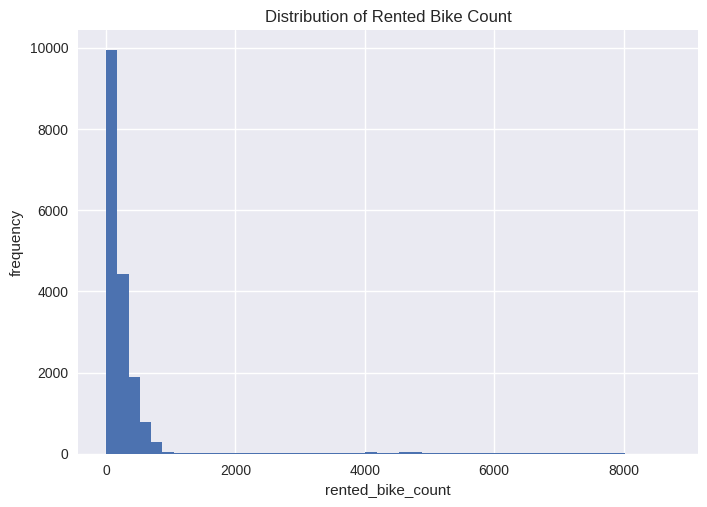

In [ ]:
#5) Target distribution
target = 'cnt'
df[target].hist(bins=50)
plt.title('Distribution of Rented Bike Count')
plt.xlabel('rented_bike_count')
plt.ylabel('frequency')

#summary stats
df[target].describe()

In [ ]:
# summary stats
df[target].describe()

,cnt
count,18110.000000
mean,363.631033
std,950.827954
min,1.000000
25%,43.000000
50%,152.000000
75%,305.000000
max,8714.000000


In [ ]:
# 6) Time-series plots&seasonality

Text(0, 0.5, 'count')

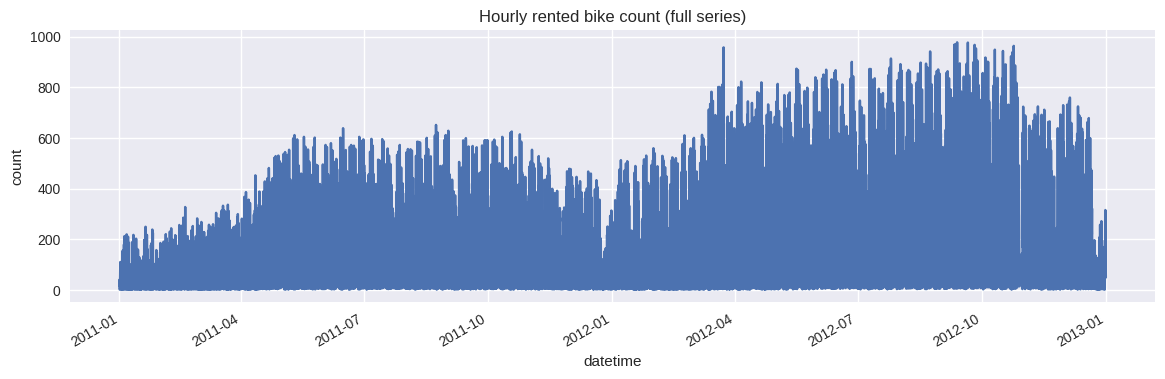

In [ ]:
#6a) plot full time series (sample, since 8760 points is fine)

plt.figure(figsize=(14,4))

df[target].plot()

plt.title('Hourly rented bike count (full series)')

plt.ylabel('count')

Text(0, 0.5, 'count')

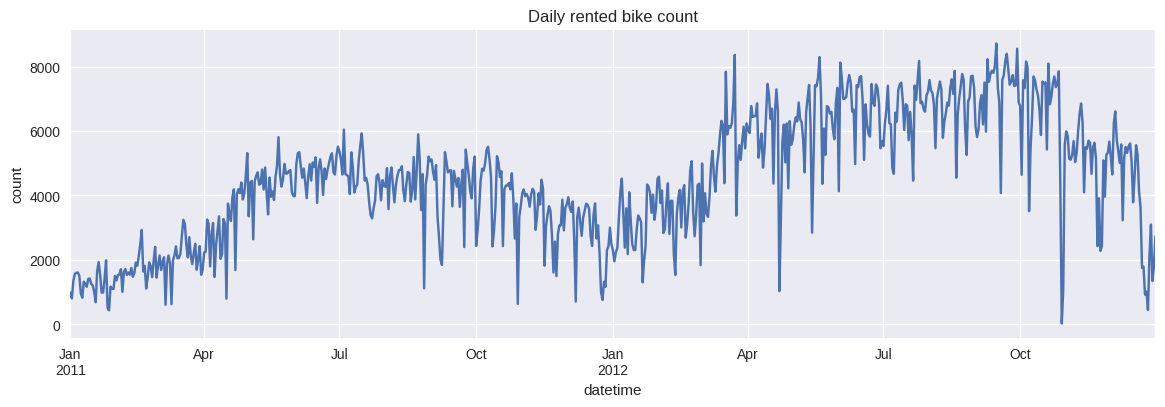

In [ ]:
# 6b) daily aggregated trend
daily = df[target].resample('D').sum()
plt.figure(figsize=(14,4))
daily.plot()
plt.title('Daily rented bike count')
plt.ylabel('count')

In [ ]:
# 7) Hour-of-day / Day-of-week / Month effects

Text(0.5, 1.0, 'Average demand by hour of day')

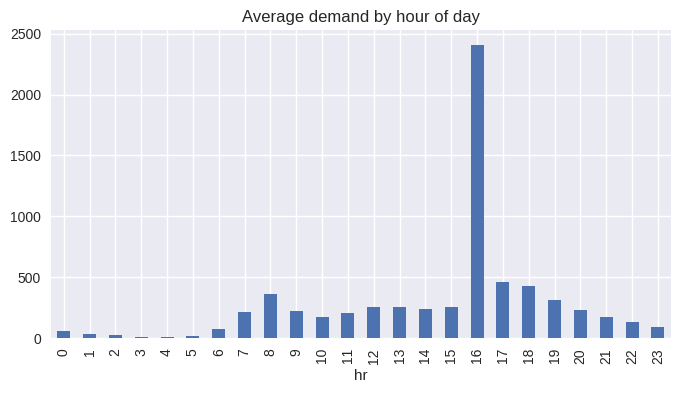

In [ ]:
#7) derive d.o.w and month if needed

# Impute missing 'hr' values with the mode before converting to int
mode_hr = df['hr'].mode()[0]
df['hr'] = df['hr'].fillna(mode_hr).astype(int)

df['month']= df.index.month

df['dayofweek']= df.index.dayofweek

hourly_mean = df.groupby('hr') [target].mean()

plt.figure(figsize=(8,4))

hourly_mean.plot(kind='bar')

plt.title('Average demand by hour of day')

In [ ]:
# boxplot by season (if season column exists)
if 'seasons' in df.columns:
  plt.figure(figsize=(8,4))
  sns.boxplot(x='seasons', y=target, data=df.reset_index())
  plt.title('Demand by season')

In [ ]:
# why: confirm commuter peaks (morning/evening), weekened vs weekday patterns,seasonal difference

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

Saving Book1 dataset merge.xlsx to Book1 dataset merge (1).xlsx


In [ ]:
df = pd.read_excel('Book1 dataset merge.xlsx')   # change name if needed
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,hr
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,NaN
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,NaN
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,NaN
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,NaN
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,NaN


In [ ]:
unwanted_cols = ['instant', 'dteday', 'yr', 'casual', 'registered']

df.drop(columns=unwanted_cols, inplace=True, errors='ignore')
print("Columns after removing unwanted:", df.columns)


Columns after removing unwanted: Index(['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'hr'],
      dtype='object')


In [ ]:
print("Null values:")
df.isnull().sum()

Null values:


,0
season,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0
hum,0
windspeed,0


In [ ]:
df = df.dropna()
print("Shape after dropping nulls:", df.shape)

Shape after dropping nulls: (17379, 12)


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (17377, 12)


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = data.shape[0]
    data = data[(data[col] >= lower) & (data[col] <= upper)]
    after = data.shape[0]

    print(f"{col}: Removed {before - after} outliers")
    return data

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

print("Final shape after removing outliers:", df.shape)

season: Removed 0 outliers
mnth: Removed 0 outliers
holiday: Removed 500 outliers
weekday: Removed 0 outliers
workingday: Removed 0 outliers
weathersit: Removed 3 outliers
temp: Removed 0 outliers
atemp: Removed 0 outliers
hum: Removed 22 outliers
windspeed: Removed 333 outliers
cnt: Removed 479 outliers
hr: Removed 0 outliers
Final shape after removing outliers: (16040, 12)


In [ ]:
df.describe()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hr
count,16040.000000,16040.000000,16040.0,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000,16040.000000
mean,2.507419,6.539027,0.0,3.028928,0.699252,1.428990,0.495012,0.474507,0.634484,0.182238,174.072007,11.415399
std,1.104579,3.434218,0.0,2.017607,0.458598,0.639491,0.192107,0.170984,0.190462,0.111906,155.992032,6.980771
min,1.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,1.000000,0.000000
25%,2.000000,4.000000,0.0,1.000000,0.000000,1.000000,0.340000,0.333300,0.490000,0.104500,38.000000,5.000000
50%,3.000000,7.000000,0.0,3.000000,1.000000,1.000000,0.500000,0.484800,0.640000,0.164200,137.000000,11.000000
75%,3.000000,10.000000,0.0,5.000000,1.000000,2.000000,0.640000,0.621200,0.790000,0.253700,268.000000,18.000000
max,4.000000,12.000000,0.0,6.000000,1.000000,3.000000,1.000000,1.000000,1.000000,0.462700,645.000000,23.000000


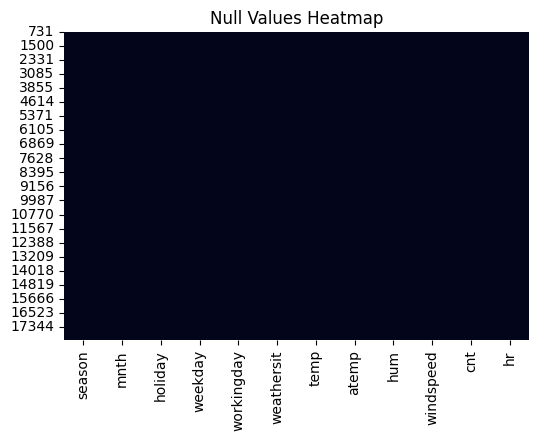

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Null Values Heatmap")
plt.show()

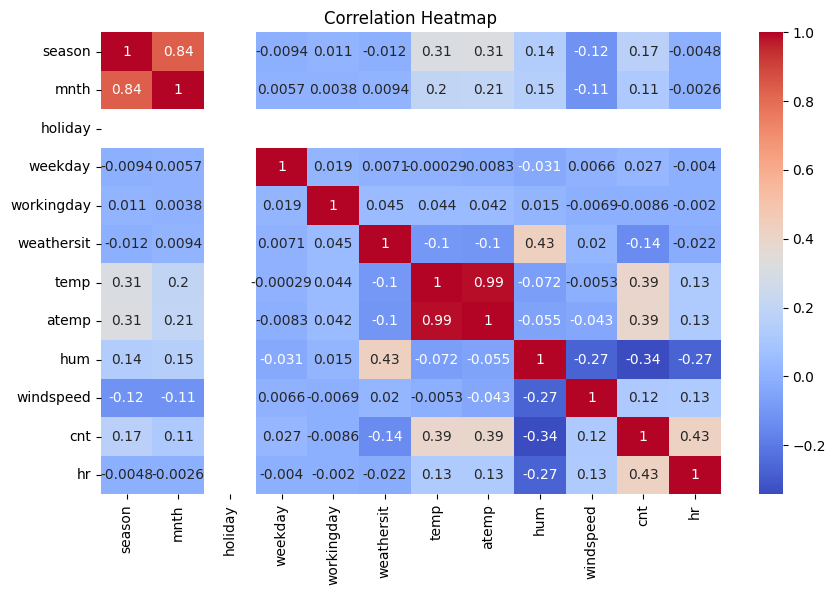

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

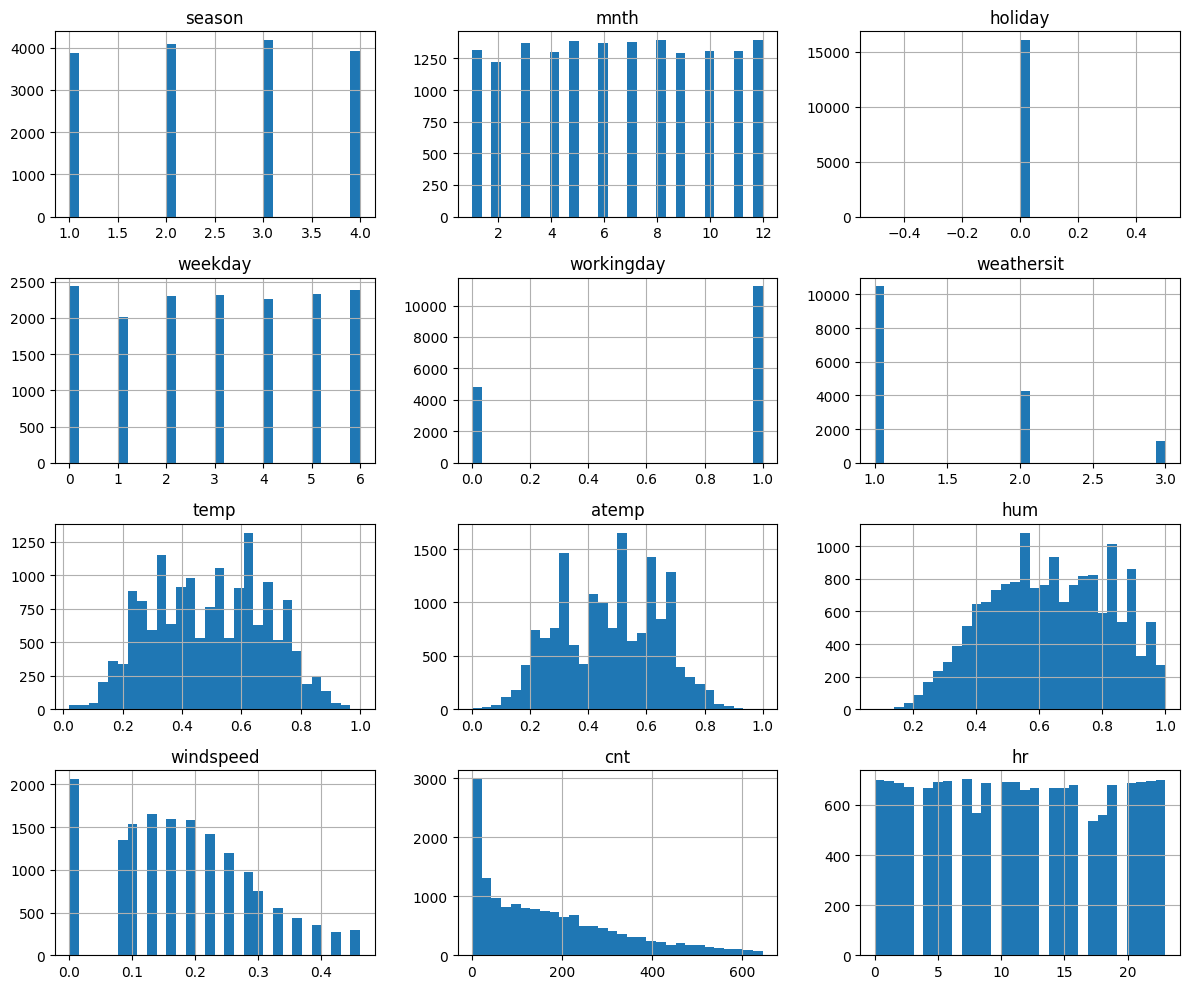

In [ ]:
df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

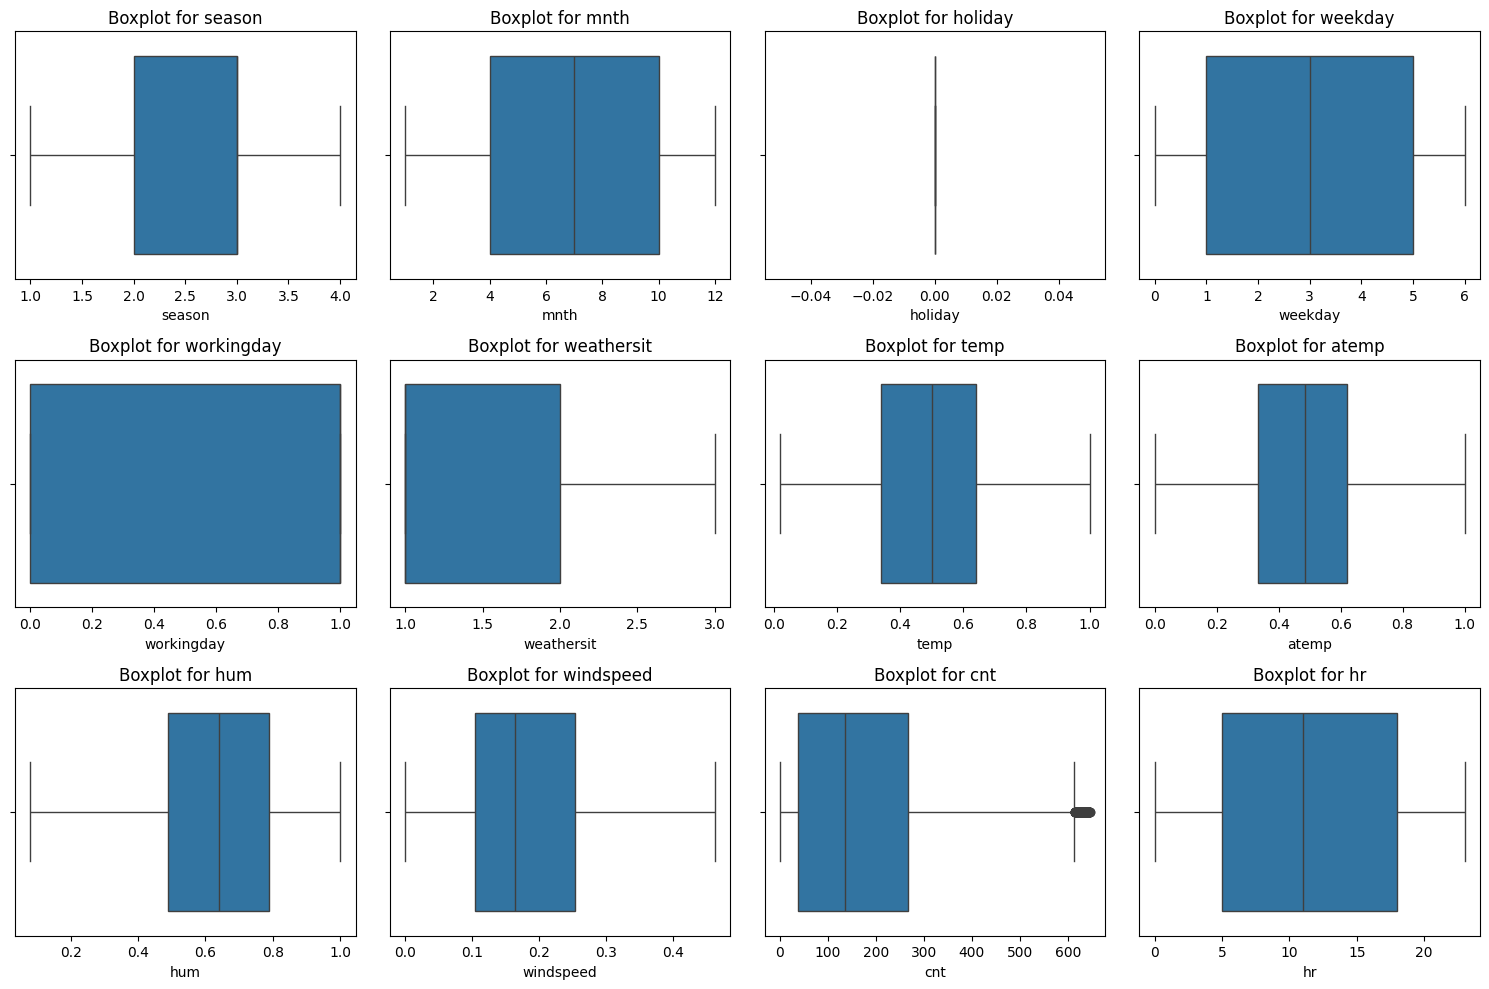

In [ ]:
plt.figure(figsize=(15, 10)) # Increased figsize for better visualization
nrows = 3
ncols = 4 # Changed to 4 columns to accommodate all 12 plots

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
plt.tight_layout()
plt.show()

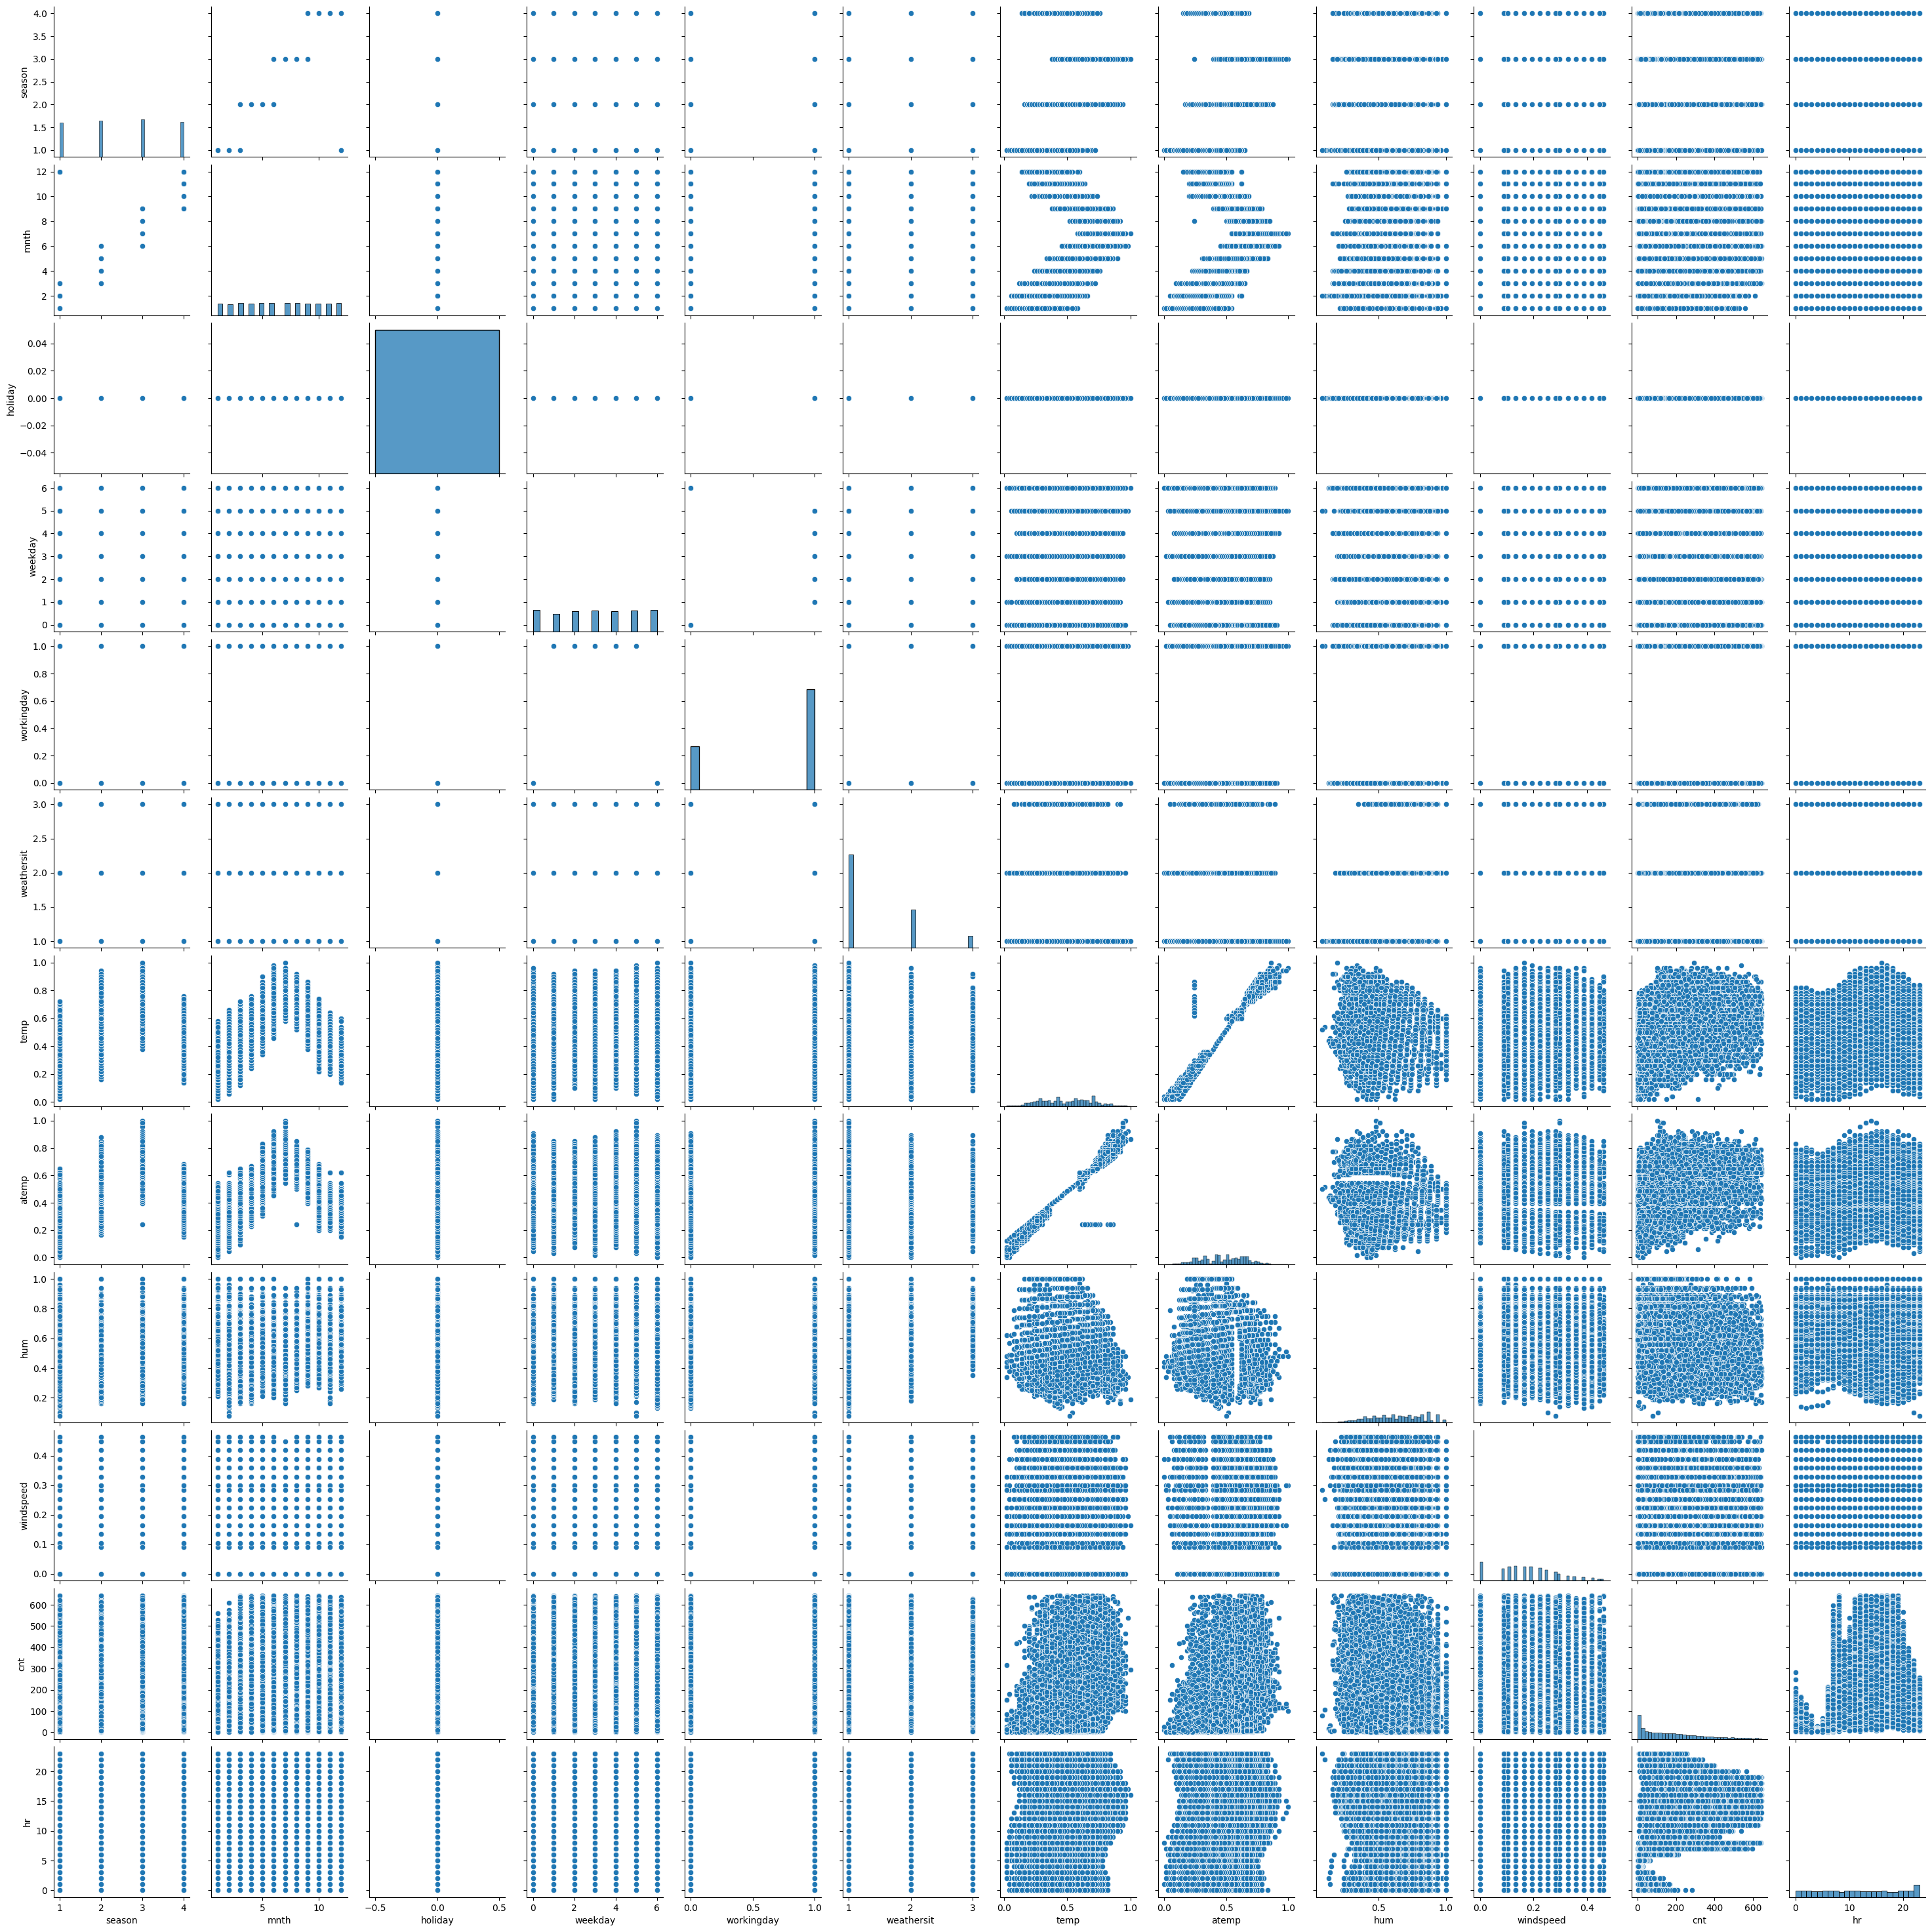

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
df.to_csv("bike_sharing_cleaned_final.csv", index=False)
print("Cleaned dataset saved as bike_sharing_cleaned_final.csv")

Cleaned dataset saved as bike_sharing_cleaned_final.csv
